<!-- <div style="display:none">
$\usepackage{bm}
    \newcommand{\dmn}[1]{~\textup{#1}}
    \newcommand{\mpss}{~\textup{m}/\textup{s}^2}
    \newcommand{\sr}[1]{{\color{MidnightBlue}{#1}}}
    \newcommand{\vr}[1]{{\color{cyan}{#1}}}
    \newcommand{\ihat}{~{\color{cyan}{\hat{\imath}}}~}
    \newcommand{\jhat}{~{\color{cyan}{\hat{\jmath}}}~}
    \newcommand{\khat}{~{\color{cyan}{\hat{k}}}~}
    \newcommand{\outpro}[2]{\vert #1\rangle\langle #2\vert}
    \newcommand{\inpro}[2]{\langle #1\vert #2\rangle}
    \newcommand{\hpro}[2]{\langle #1, #2\rangle}
    \newcommand{\dotpro}[2]{\vec{#1}\cdot\vec{#2}}
    \newcommand{\expect}[3]{\langle #1\vert #2\vert #3\rangle}
    \newcommand{\ket}[1]{\vert #1\rangle}
    \newcommand{\bra}[1]{\langle #1\vert}
    \newcommand{\modulus}[1]{\vert #1 \vert}
    \newcommand{\tr}[1]{\mathsf{Tr}(#1)}
    \newcommand{\ptr}[2]{\mathsf{Tr}_{#1}(#2)}
    \newcommand{\kernel}[1]{\mathsf{Ker}(#1)}
    \newcommand{\rank}[1]{\mathsf{rank}(#1)}
    \renewcommand{\dim}[1]{\mathsf{dim}(#1)}
    \newcommand{\im}[1]{\mathsf{im}(#1)}
    \newcommand{\norm}[1]{\lVert #1\rVert}
    \newcommand{\prob}[1]{\mathsf{P}(#1)}
    \newcommand{\redheart}{{\color{red}\heartsuit}}
    \newcommand{\reddiamond}{{\color{red}\diamondsuit}}$
</div> -->

# Contents
* What is Quantum Programming?
* Practical problems and applications
* About the course
* Quantum mechanics review

# Quantum Programming
* Quantum programming is the process of designing sequences of **unitary transformations** (gates) to manipulate the **probability amplitudes** of a quantum system to solve a computational problem.
* Qiskit is a python library, developed by IBM, that can be used to code quantum algorithms which can be *run* on a quantum computer.

# Languages
[#Languages](https://en.wikipedia.org/wiki/Quantum_programming)
### Imperative languages
* Ket : similar to python
* Q#
* Silq
* ...
### Functional languages
* Quipper : based on Haskell
* QPL
* QML
* ...
### Software Development Kits
* Qiskit : python (IBM)
* Cirq : python (Google)
* Quantum Development Kit : Q# (Microsoft)
* ...

# History
### Theory
* 1980 : Quantum Turing Machine by Paul Benioff
* 1982 : Quantum computers for simulation by Richard Feynman
* 1985 : Quantum Circuit Model by David Deutsch
### Algorithms
* 1985 : Deutsch algorithm
* 1994 : Quantum Fourier Transform by Peter Shor
* 1996 : Quantum Search by Lov Grover
### Experiments
* 1998 : Deutsch-Jozsa algorithm using NMR by IBM and Oxford
* 2001 : Shor's algorithm to factor 15 using NMR by IBM and Stanford
* 2007-09 : Transmon qubits at Yale
* 2011 : Quantum Annealing by D-Wave
### Circuit Languages
* 2011 : Quipper
* 2016 : IBM circuit composer 
* 2017 : OpenOASM by IBM
### SDKs
* 2017 : Qiskit by IBM, Cirq by Google, OpenQASM by IBM
* 2018 : Forest by Rigetti
* 2019 : PennyLane by Xanadu
* 2020-21 : Braket by Amazon

# Structure of Quantum programming
[Hello World](https://quantum.cloud.ibm.com/docs/en/tutorials/hello-world)

### 1. Ideal circuit

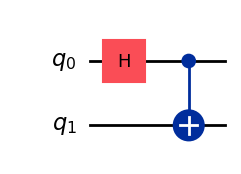

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.draw("mpl")

### 2. Hardware specific transpilation

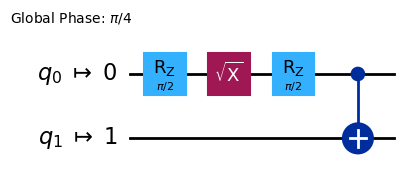

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

### 3. Execute on simulator or quantum processor

In [3]:
observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()
 
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
 
job_result = job.result()
 
# This is the result from our single pub, which had five observables,
# so contains information on all five.
 
pub_result = job.result()[0]

### 4. Analyze the results

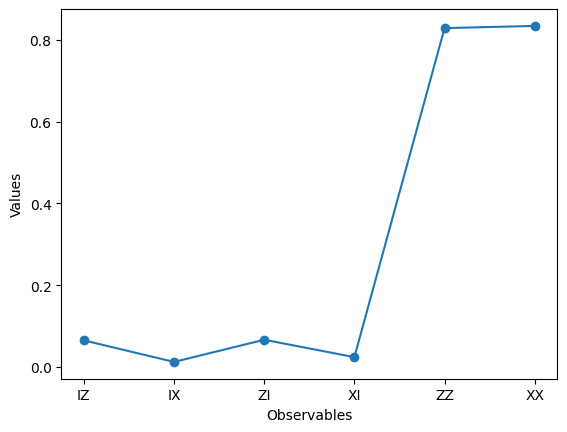

In [4]:
# Plot the result
 
from matplotlib import pyplot as plt
values = pub_result.data.evs
errors = pub_result.data.stds
 
# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

## Practical problems (NISQ: Noisy Intermediate-Scale Quantum)
* Topology : Cross-talk
* Decoherence and gate noise
* Measurement error
* Specific basis gate

# Types of applications
* Fourier transform based : Shor's factoring
* Amplitude amplification : Grover's search
* Parameterize quantum circuits
    * Simulation
    * Optimization
    * Machine learning

# About the Course
* Review Quantum Mechanics (Dirac notation)
* Qiskit
* Evaluation
    * Projects - 40%
    * Assignments - 40%
    * Mid term - 20%
* Meeting on Thursday for project (1 hour)

# Qiskit
* Circuit composer
* Python
* Jupyter notebook
* SDK

# Toy Example

## A Quantum die
* A die has 6 faces. When a rolled die lands, the top face can be 1, 2, 3, 4, 5 or 6.
* We say that a landed die can be in one of the face states $\ket{1},\ket{2},\dots,\ket{6}$.
* The state of the die before it has landed will be written as $$\ket{\psi}=\frac{1}{\sqrt{6}}\left(\ket{1} + \ket{2} + \ket{3} + \ket{4} + \ket{5} + \ket{6}\right)$$
* When it lands, with probability $\frac{1}{6}$, the state collapses to one of the face states.

## Two Quantum Dice
* Imagine rolling two quantum dice. There are 36 possible outcomes $$\{1,2,3,4, 5, 6\}\times \{1,2,3,4, 5, 6\}$$
* We say that landed dice are in one of the face states $\ket{11}, \ket{12},\dots \ket{66}$.
* The state of the dice before they have landed will be written as $$\ket{\psi}=\frac{1}{\sqrt{6}}\left(\ket{1} + \ket{2} + \cdots + \ket{6}\right)\otimes\frac{1}{\sqrt{6}}\left(\ket{1} + \ket{2} + \cdots + \ket{6}\right)$$
* At this point, we can allow either both to land or only one to land. Say the second one landed and the outcome was $\ket{4}$. Then the state will be $$\ket{\phi} = \frac{1}{\sqrt{6}}\left(\ket{1} + \ket{2} + \cdots + \ket{6}\right)\otimes \ket{4}$$

## Connected Dice
* Now suppose the two dice are glued together at faces with value 1 with the same orientation of other faces. (Assume 6 is at opposite end and we only roll horizontally).
* In such a case, the state of un-rolled dice will be written as $$\ket{\psi} = \frac{1}{2}\left(\ket{22} + \ket{33} + \ket{44} + \ket{55} \right)$$
* At this point, if 2nd die is allowed to land, and outcome is say $\ket{4}$, then the 1st one also lands in $\ket{4}$, i.e. the final states becomes $$\ket{\phi} = \ket{44}$$
* Notice that $\ket{\psi}$ can not be expressed as $\ket{\psi_1}\otimes\ket{\psi_2}$.

# Quantum description
* State of a quantum die lie in a Hilbert space $\mathcal{H}$ of dimension 6.
* Face is an observable.
* Measurement is the process of letting the die land and read the outcome.
* Evolution is process of rolling the die.

# Quantum Mechanics
### Postulate 1
* At any time, the state of an isolated system is described by a unit vector in a Hilbert space.
### Postulate 2
* Evolution of the state of an isolated system is determined by a (time evolution) unitary operator. 
### Postulate 3
* Measurement of an observable projects the state to one of the eigenspaces of the observable with probability given by the modulus square of the corresponding component.
### Postulate 4
* The Hilbert spaces of two systems are provided by the tensor product of Hilber spaces of individual systems.